In [27]:
import numpy as np
import pandas as pd
from scipy.constants import k as k_B
import matplotlib.pyplot as plt
from scipy import stats

In [28]:
def singleRunData(initial_path):
  components = ['x', 'y', 'z']
  ppe = None
  per_component = []
  for i, c in enumerate(components):
    data = pd.read_csv(f"{initial_path}_T_{c}_0001.csv")
    columns = [column for column in data.columns if column.startswith("T_")]
    if (i == 0):
      ppe = data["N_p_0"][0]

    data = data[columns]
    data = data.to_numpy()[0]
    per_component.append(data)
#    temporary = np.histogram(data, bins=50, density=True)
#    temp_pdfs.append(temporary[0])
#    temp_centers.append((temporary[1][1:] + temporary[1][:-1]) / 2.0)
#    temp_widths.append(temporary[1][1:] - temporary[1][:-1])

  return ppe, per_component

ppe, per_component = singleRunData("data/run_0")

In [29]:
def collectSamples(folder, runs):
  ppe_vals = np.zeros((runs, 1), dtype=float)
  per_component = [np.empty(0) for i in range(3)]
  all_samples = None

  for i in range(runs):
    file_start = f"{folder}/run_{i}"
    ppe_vals[i], run_per_component = singleRunData(file_start)
    for j in range(3):
      if i == 0:
        per_component[j] = run_per_component[j]
      else:
        per_component[j] = np.hstack(( per_component[j], run_per_component[j] ))

      if i == 0 and j == 0:
        all_samples = run_per_component[j]
        continue
      all_samples = np.hstack((all_samples, run_per_component[j]))

  return ppe_vals, per_component, all_samples
ppe, per_component, alll_samples = collectSamples("data", 10)

In [30]:
def histogramFromData(data):
    hist = np.histogram(data, bins=50, density=True)
    values = hist[0]
    centers = (hist[1][1:] + hist[1][:-1]) / 2.0
    widths = hist[1][1:] - hist[1][:-1]
    return values, centers, widths


In [31]:
def actualVSExpectedVariance(actual_mean, data, particles_averaged):
  num_samples = len(data)
  measured_mean = data.mean()
  measured_relative_var = np.sqrt(((data - actual_mean)**2).sum() / num_samples) / actual_mean
  expected_relative_var = np.sqrt(2 / particles_averaged)


  print(f"Expected Mean : {actual_mean}")
  print(f"Measured Mean : {measured_mean}")
  print(f"Expected Relative Var  : {expected_relative_var}")
  print(f"Measured Relative Var  : {measured_relative_var}")

# Per Element Per Component Temperatures 

Component 0
Expected Mean : 273.15
Measured Mean : 272.9823815064847
Expected Relative Var  : 0.044721359549995794
Measured Relative Var  : 0.04534480132810694

Component 1
Expected Mean : 273.15
Measured Mean : 273.0550512208415
Expected Relative Var  : 0.044721359549995794
Measured Relative Var  : 0.044658785500558004

Component 2
Expected Mean : 273.15
Measured Mean : 273.0859734553557
Expected Relative Var  : 0.044721359549995794
Measured Relative Var  : 0.04491741007939083



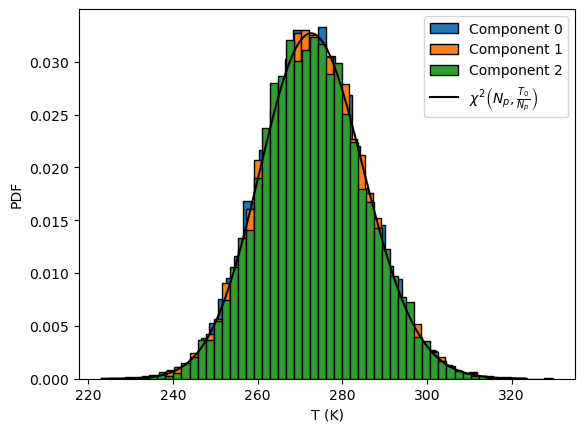

Component 2
Expected Mean : 273.15
Measured Mean : 273.0411353942273
Expected Relative Var  : 0.044721359549995794
Measured Relative Var  : 0.044974555243717164



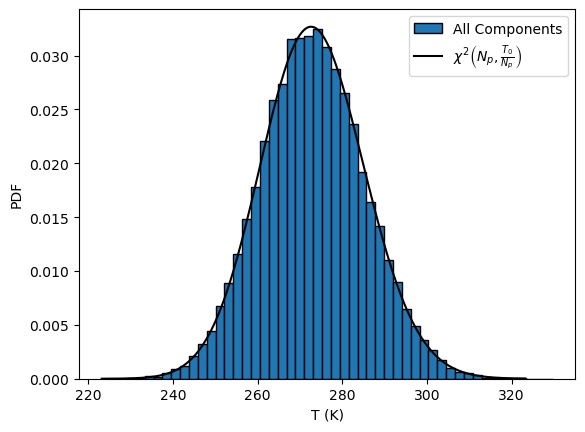

In [36]:
runs = 100
elems_per_dim = 10
ppes, per_component, all_samples = collectSamples("data", runs)

T_true = 273.15
delta_T = 100
T_range = np.linspace(T_true - delta_T / 2, T_true + delta_T / 2, 1000)
ppe = ppes[0]

plt.figure()
for i, samples in enumerate(per_component):
  plt.hist(samples,bins=50, density=True, edgecolor='k', label=f"Component {i}")
  print(f"Component {i}")
  actualVSExpectedVariance(T_true, samples, ppe[0])
  print()
plt.plot(T_range, stats.chi2.pdf(T_range, df=ppe, scale=T_true / (ppe)),  '-k', label='$\\chi^2 \\left(N_p,\\frac{T_0}{N_p}\\right)$')
plt.ylabel("PDF")
plt.xlabel("T (K)")
plt.legend()
plt.show()

plt.figure()
plt.hist(all_samples, bins=50, density=True, edgecolor='k', label='All Components')
print(f"Component {i}")
actualVSExpectedVariance(T_true, all_samples, ppe[0])
print()
plt.plot(T_range, stats.chi2.pdf(T_range, df=ppe, scale=T_true / (ppe)),  '-k', label='$\\chi^2 \\left(N_p,\\frac{T_0}{N_p}\\right)$')
plt.ylabel("PDF")
plt.xlabel("T (K)")
plt.legend()
plt.show()


# Per Domain Per Component Averages

Component 0
Expected Mean : 273.15
Measured Mean : 272.9823815064848
Expected Relative Var  : 0.00447213595499958
Measured Relative Var  : 0.005245152125297143

Component 1
Expected Mean : 273.15
Measured Mean : 273.0550512208415
Expected Relative Var  : 0.00447213595499958
Measured Relative Var  : 0.00461084449125711

Component 2
Expected Mean : 273.15
Measured Mean : 273.0859734553557
Expected Relative Var  : 0.00447213595499958
Measured Relative Var  : 0.004636056690952333



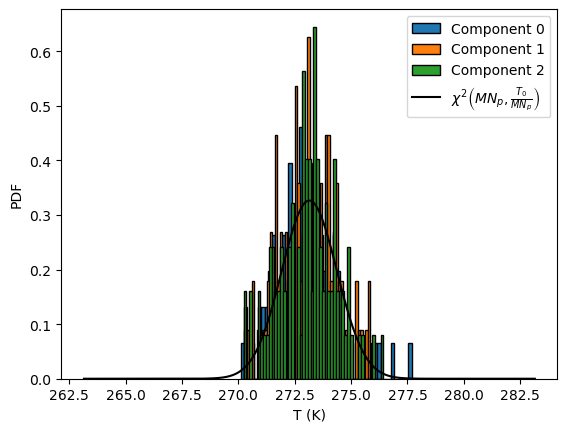

Component 2
Expected Mean : 273.15
Measured Mean : 273.04113539422735
Expected Relative Var  : 0.00447213595499958
Measured Relative Var  : 0.004839577439604587



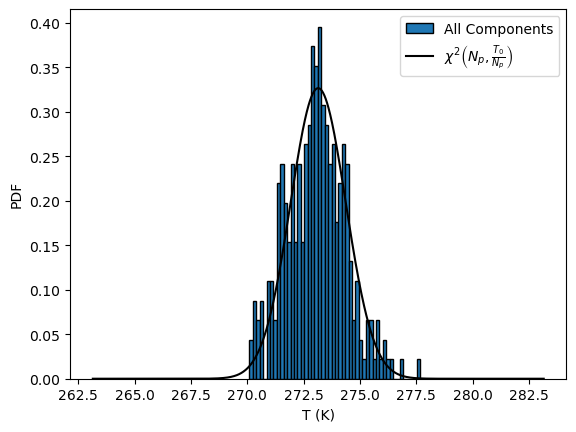

In [54]:
delta_T = 20
T_range = np.linspace(T_true - delta_T / 2, T_true + delta_T / 2, 1000)

per_simulation = [component_data.reshape((runs, elems_per_dim**2)).mean(axis=1) for component_data in per_component]
all_per_sim_samples = per_simulation[0]

for per_sim in per_simulation[1:]:
  all_per_sim_samples = np.hstack((all_per_sim_samples, per_sim))
plt.figure()
for i, samples in enumerate(per_simulation):
  plt.hist(samples,bins=50, density=True, edgecolor='k', label=f"Component {i}")
  print(f"Component {i}")
  actualVSExpectedVariance(T_true, samples, ppe[0] * elems_per_dim**2)
  print()
plt.plot(T_range, stats.chi2.pdf(T_range, df=ppe * elems_per_dim**2, scale=T_true / (ppe * elems_per_dim**2)),  '-k', label='$\\chi^2 \\left(M N_p,\\frac{T_0}{M N_p}\\right)$')
plt.ylabel("PDF")
plt.xlabel("T (K)")
plt.legend()
plt.show()

plt.figure()
plt.hist(all_per_sim_samples, bins=50, density=True, edgecolor='k', label='All Components')
print(f"Component {i}")
actualVSExpectedVariance(T_true, all_per_sim_samples, ppe[0] * elems_per_dim**2)
print()
plt.plot(T_range, stats.chi2.pdf(T_range, df=ppe[0] * elems_per_dim**2, scale=T_true / (ppe[0] * elems_per_dim**2)),  '-k', label='$\\chi^2 \\left(N_p,\\frac{T_0}{N_p}\\right)$')
plt.ylabel("PDF")
plt.xlabel("T (K)")
plt.legend()
plt.show()



# Per Component For All Runs 

In [75]:
delta_T = 20
T_range = np.linspace(T_true - delta_T / 2, T_true + delta_T / 2, 1000)
all_runs = [np.array([ all_sim.mean() ]) for all_sim in per_simulation]
for i, run in enumerate(all_runs):
  print(f"Component {i}")
  actualVSExpectedVariance(T_true, all_runs[i], runs * ppe[0] * elems_per_dim**2)
  print()

print(0.0179/ 10**2)


Component 0
Expected Mean : 273.15
Measured Mean : 272.9823815064848
Expected Relative Var  : 0.00044721359549995795
Measured Relative Var  : 0.0006136499854116505

Component 1
Expected Mean : 273.15
Measured Mean : 273.0550512208415
Expected Relative Var  : 0.00044721359549995795
Measured Relative Var  : 0.0003476067331446881

Component 2
Expected Mean : 273.15
Measured Mean : 273.0859734553557
Expected Relative Var  : 0.00044721359549995795
Measured Relative Var  : 0.00023440067598119735

0.000179
